<a href="https://colab.research.google.com/github/cta48/GeoData-Soil-Moisture-Sensors/blob/main/Owner_avatar_GeoData_Soil_Moisture_Sensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


CampsRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/CAMPS.csv'
CampsData = pd.read_csv(CampsRaw, skiprows=4)

CenseRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/CENSE.csv'
CenseData = pd.read_csv(CenseRaw, skiprows=4)

GlitzRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/GLITZ.csv'
GlitzData = pd.read_csv(GlitzRaw, skiprows=4)

GraspRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/GRASP.csv'
GraspData = pd.read_csv(GraspRaw, skiprows=4)

NinjaRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/NINJA.csv'
NinjaData = pd.read_csv(NinjaRaw, skiprows=4)

WeatherRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/IthacaWeather.csv'
WeatherData = pd.read_csv(WeatherRaw, header=0)
#note - weather data is pre processed - fingers crossed
# Putting them ina dict so its easier to loop
datasets = {
    "CAMPS": CampsData,
    "GLITZ": GlitzData,
    "CENSE": CenseData,
    "GRASP": GraspData,
    "NINJA": NinjaData,
    }

# Parse timestamps and make sure data is numeric so no --- and stuffs

for name, df in datasets.items():
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
  df["volumetric_water_content[%]"] = pd.to_numeric(df["volumetric_water_content[%]"], errors="coerce")
  df[" vwc_raw[V]"] = pd.to_numeric(df[" vwc_raw[V]"], errors="coerce") # why is there a space rip
  df["battery[V]"] = pd.to_numeric(df["battery[V]"], errors="coerce")



testing github sync
- works but need to save directly to main branch after each update, so can't really work simultaneously?


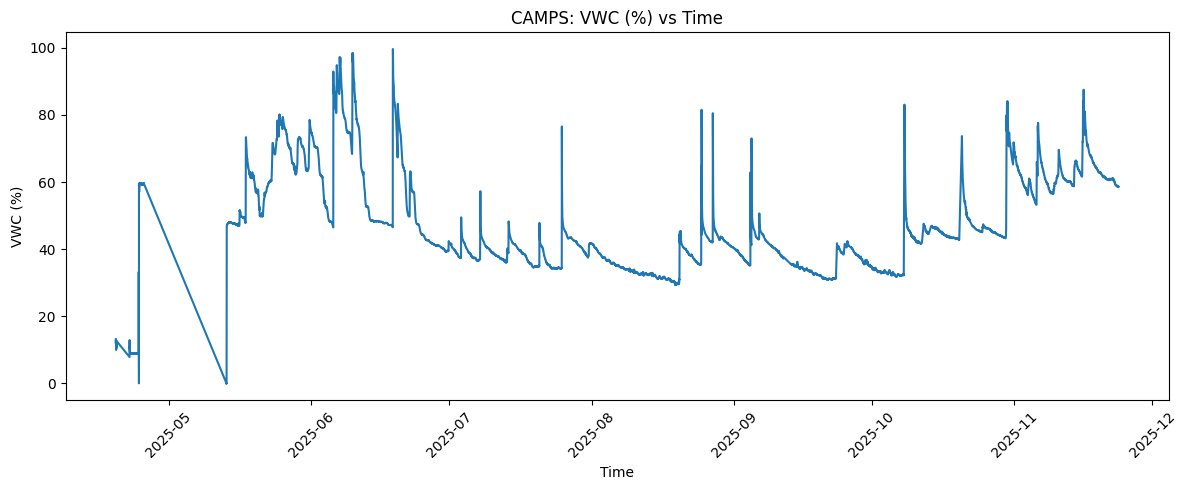

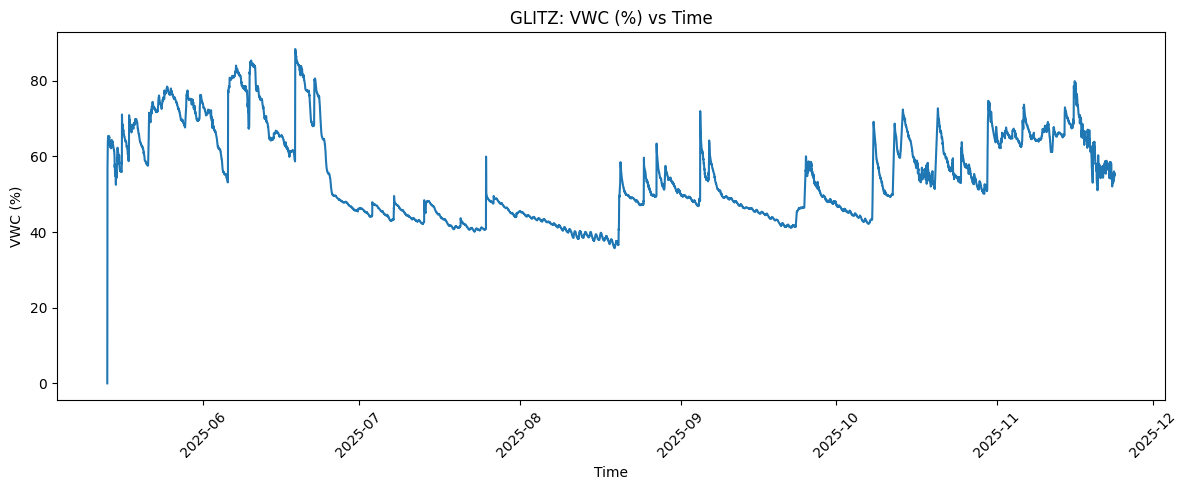

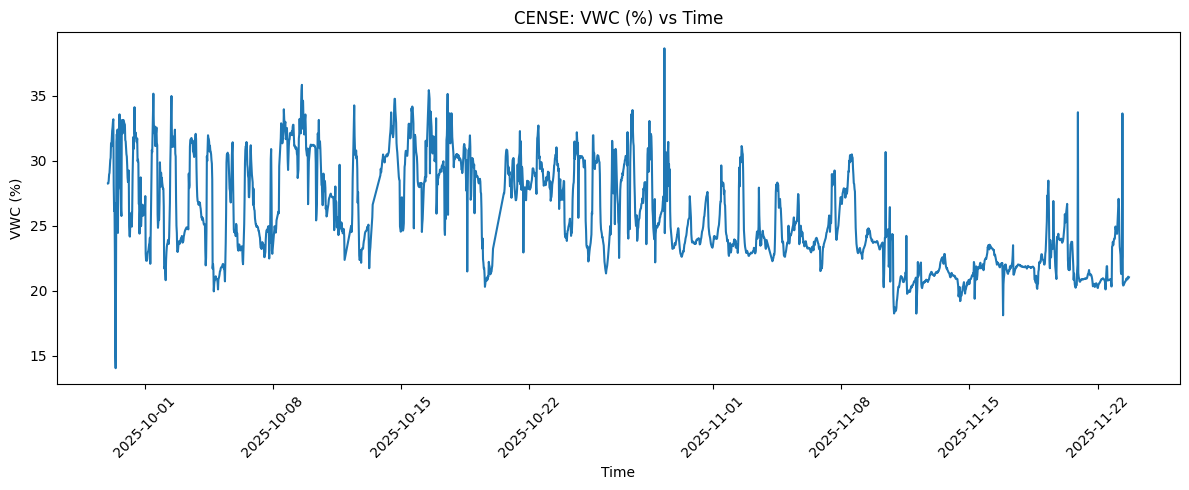

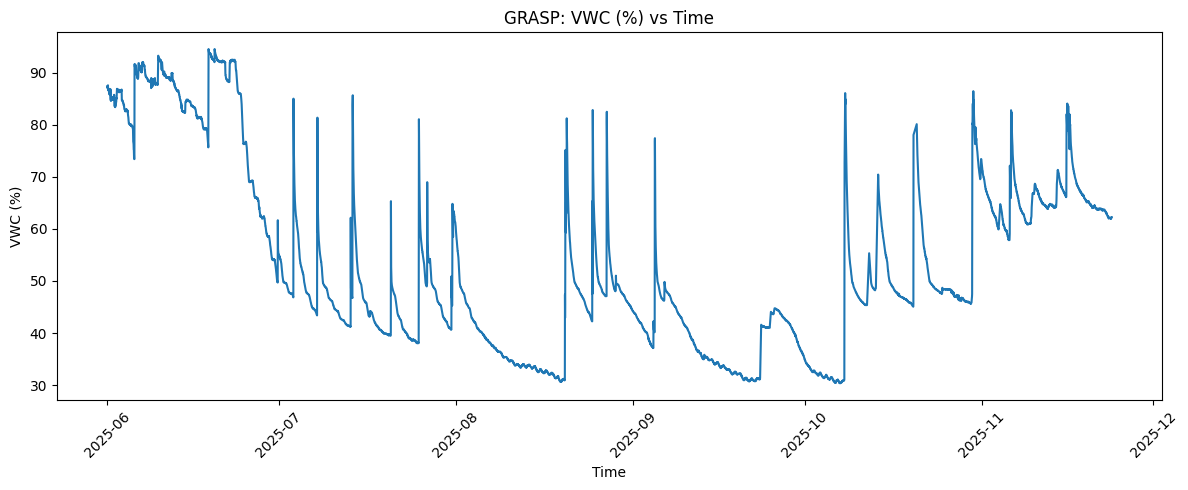

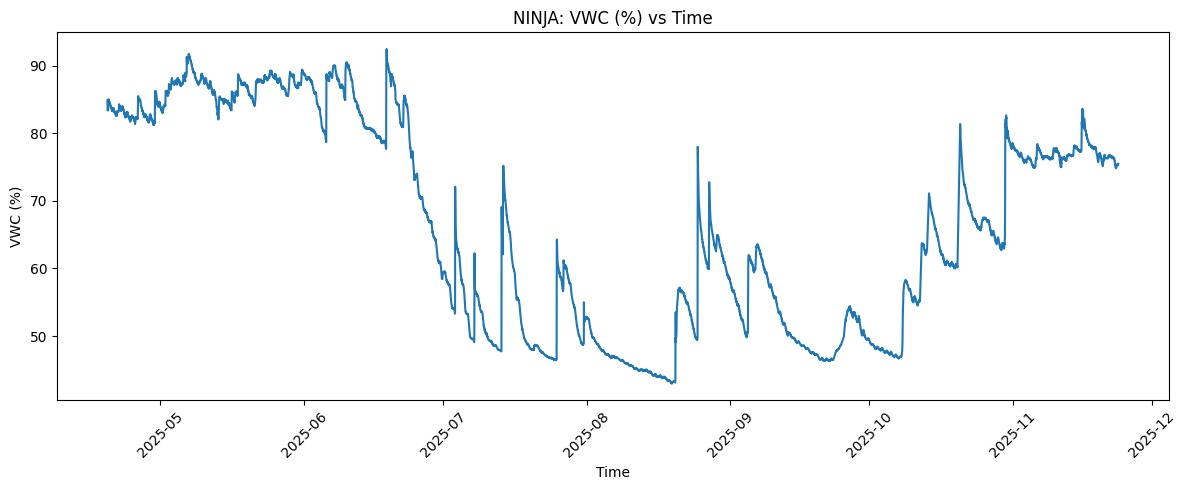

In [4]:
# Plot Data against Time

for name, df in datasets.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"])
    plt.xlabel("Time")
    plt.ylabel("VWC (%)")
    plt.title(f"{name}: VWC (%) vs Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

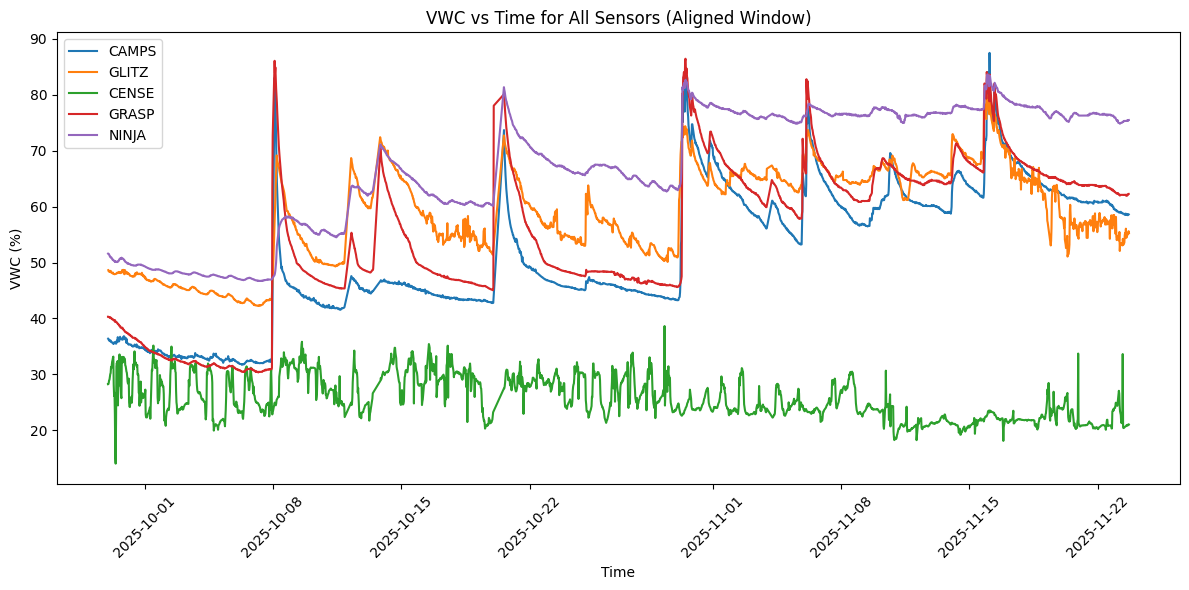

In [5]:
# Find common time period
common_start = max(df["timestamp"].min() for df in datasets.values())
common_end = min(df["timestamp"].max() for df in datasets.values())

overlap = {}
for name, df in datasets.items():
    overlap[name] = df[(df["timestamp"] >= common_start) & (df["timestamp"] <= common_end)].copy()

# Plot in one graph to compare over common timeframe
plt.figure(figsize=(12, 6))
for name, df in overlap.items():
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"], label=name)
plt.xlabel("Time")
plt.ylabel("VWC (%)")
plt.title("VWC vs Time for All Sensors (Aligned Window)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*NOTES*

- Overlapping time period is restricted by CENSE, it has a very short time period
- CENSE doesn't seem to follow the same trend?
maybe it was on different soil type? the water flow is shielded? broken?
- There are periodic spikes in VWC which is agreed upon by (most) of the sensors
- After each spike the water level is then shifted up

Next:

- remove CENSE and see what happens on a larger time scale?

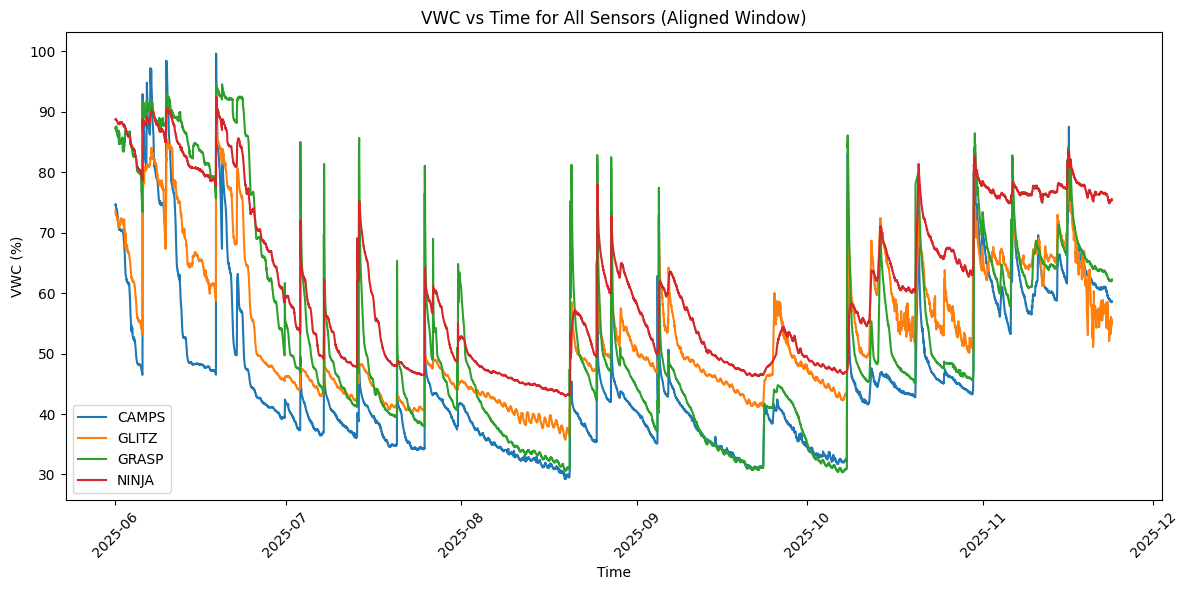

In [45]:
# Re-try without CENSE

common_start_NOCENSE = max(df["timestamp"].min() for name, df in datasets.items() if name != "CENSE")

common_end_NOCENSE = min(df["timestamp"].max() for name, df in datasets.items() if name != "CENSE")

overlap_NOCENSE = {}
for name, df in datasets.items():
    if name == "CENSE":
        continue
    overlap_NOCENSE[name] = df[(df["timestamp"] >= common_start_NOCENSE) & (df["timestamp"] <= common_end_NOCENSE)].copy()

plt.figure(figsize=(12, 6))
for name, df in overlap_NOCENSE.items():
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"], label=name)
plt.xlabel("Time")
plt.ylabel("VWC (%)")
plt.title("VWC vs Time for All Sensors (Aligned Window)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print("hello!")

hello!


**NOTES**
- Same periodic cycle as before, but now we can see that it dips slightly in the Fall season

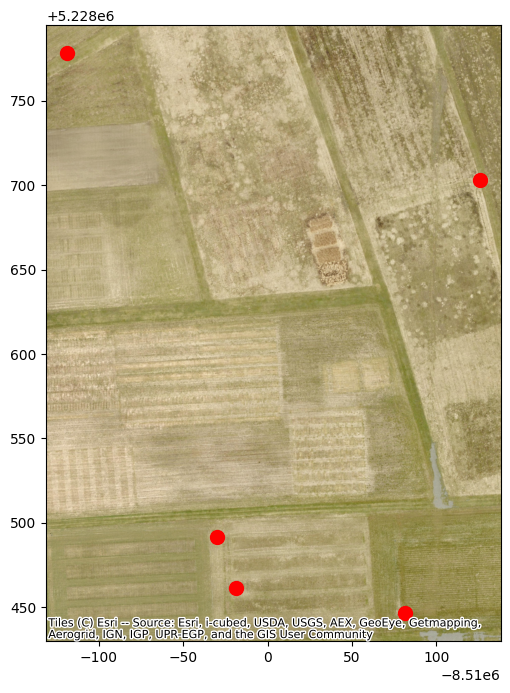

In [44]:
import geopandas as gpd
import contextily as ctx

coordinates = pd.DataFrame(
    {
        "Sensor Name": ["Cense",  "Ninja",   "Camps",   "Grasp",   "Glitz"],
        "Latitude":    [42.4489,  42.4488,   42.4505,   42.4510,   42.4491],
        "Longitude":   [-76.4468, -76.4459,  -76.4455,  -76.4477,  -76.4469],
    }
)
gdf = gpd.GeoDataFrame(
    coordinates,
    geometry=gpd.points_from_xy(coordinates.Longitude, coordinates.Latitude),
     crs="EPSG:4326"
).to_crs(epsg=3857)# tells it the scale of coordinates
gdf.head()

gdp_plot = gdf.plot(color="red", markersize=100, figsize=(8, 8))

ctx.add_basemap(gdp_plot, zoom=20,source=ctx.providers.Esri.WorldImagery)
plt.show()